In [29]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.single_variable.newton import newton
from src.single_variable.damped_newton import damped_newton
from src.single_variable.adaptive_damped_newton import adaptive_damped_newton

In [40]:
def f(x):
    return np.tan(x) - x - 1


def df(x):
    return 1 / np.cos(x)**2 - 1

In [41]:
x0 = 0.5

methods = {
    "Newton": newton(f, df, x0, max_iter=75),
    "Constant Damped Newton": damped_newton(
        f, df, x0, alpha=0.25, backtracking=False, max_iter=75
    ),
    "Adaptive Armijo Newton": adaptive_damped_newton(
        f, df, x0, max_iter=75
    ),
}

In [42]:
summary = []

for name, result in methods.items():
    summary.append({
        "Method": name,
        "Root": result["root"],
        "Converged": result["converged"],
        "Iterations": result["iterations"],
        "Final Error": result["final_error"],
        "Final Residual": result["final_residual"],
        "Message": result["message"],
    })

df_summary = pd.DataFrame(summary)
df_summary

,Method,Root,Converged,Iterations,Final Error,Final Residual,Message
0,Newton,4.448710e+40,False,75,6.446513e+39,4.448710e+40,maximum iterations reached
1,Constant Damped Newton,1.132268e+00,True,58,8.432080e-09,1.150110e-07,converged by step tolerance
2,Adaptive Armijo Newton,1.132268e+00,True,5,1.608245e-05,3.059162e-09,converged by residual tolerance


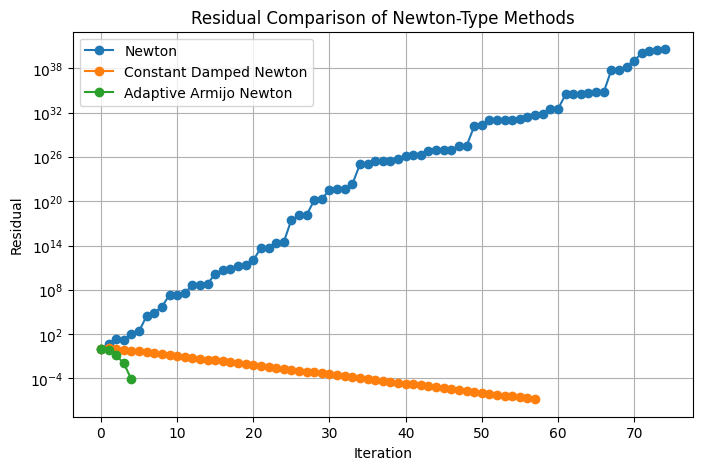

In [43]:
plt.figure(figsize=(8, 5))

for name, result in methods.items():

    residuals = []

    for step in result["history"]:
        if "residual" in step:
            residuals.append(step["residual"])
        elif "fx" in step:
            residuals.append(abs(step["fx"]))

    if residuals:
        plt.semilogy(
            range(len(residuals)),
            residuals,
            marker="o",
            label=name
        )

plt.xlabel("Iteration")
plt.ylabel("Residual")
plt.title("Residual Comparison of Newton-Type Methods")

plt.legend()
plt.grid(True)

plt.savefig(
    "outputs/figures/armijo_residual_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

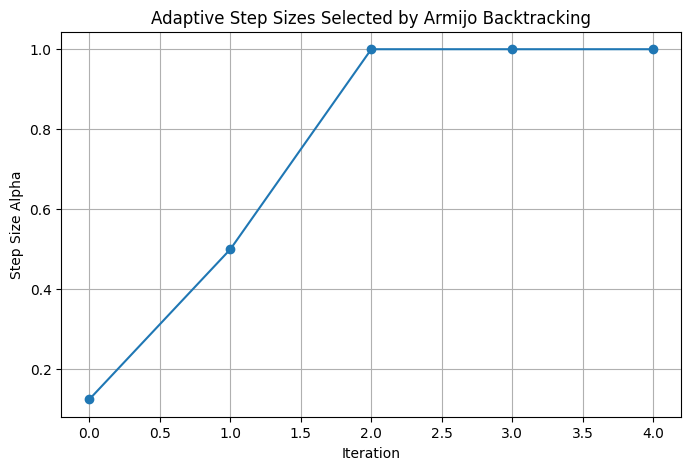

In [44]:
adaptive_history = methods["Adaptive Armijo Newton"]["history"]

alphas = [step["alpha"] for step in adaptive_history]

plt.figure(figsize=(8, 5))

plt.plot(
    range(len(alphas)),
    alphas,
    marker="o"
)

plt.xlabel("Iteration")
plt.ylabel("Step Size Alpha")
plt.title("Adaptive Step Sizes Selected by Armijo Backtracking")

plt.grid(True)

plt.savefig(
    "outputs/figures/armijo_alpha_history.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()